# VEV Options Analysis: Volatility Smile + Detrending

Goal: extract *relative* mispricing across strikes by building a volatility smile and detrending it.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

DATA_DIR = 'round3/'

## Load data

In [100]:
days = [0, 1, 2]
TTE = 5 / 365  # constant for all of round 3

dfs = []
for d in days:
    df = pd.read_csv(f'{DATA_DIR}prices_round_3_day_{d}.csv', sep=';')
    df['day'] = d
    df['tte'] = TTE
    dfs.append(df)
prices = pd.concat(dfs, ignore_index=True)

STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f'VEV_{k}' for k in STRIKES]

spot = (prices[prices['product'] == 'VELVETFRUIT_EXTRACT']
        [['day', 'timestamp', 'mid_price']]
        .rename(columns={'mid_price': 'spot'}))
print(f'spot rows: {len(spot)}')
prices.head(3)

spot rows: 30000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,tte
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0,0.013699
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0,0.013699
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0,0.013699


## Black-Scholes IV

**What is implied volatility (IV)?**

Black-Scholes gives a call option price as a function of: spot S, strike K, time-to-expiry T, risk-free rate r, and *volatility* σ. Everything except σ is observable. So we can *invert*: given the market price of an option, what σ makes B-S match that price? That σ is the **implied volatility** — the market's estimate of future vol baked into that option's price.

We assume r=0 (competition simplification).

In [101]:
def bs_call(S, K, T, sigma):
    """Black-Scholes call price, r=0."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def implied_vol(market_price, S, K, T, lo=1e-4, hi=10.0):
    """Brent root-find for IV. Returns NaN if no solution."""
    intrinsic = max(S - K, 0.0)
    if market_price <= intrinsic:
        return np.nan
    try:
        return brentq(lambda s: bs_call(S, K, T, s) - market_price, lo, hi, xtol=1e-6)
    except ValueError:
        return np.nan

# quick sanity check
print(f'BS call(S=5200, K=5000, T=5/365, σ=0.5): {bs_call(5200, 5000, 5/365, 0.5):.2f}')
print(f'IV back-solve: {implied_vol(bs_call(5200, 5000, 5/365, 0.5), 5200, 5000, 5/365):.4f}')

BS call(S=5200, K=5000, T=5/365, σ=0.5): 244.82
IV back-solve: 0.5000


## Compute IV per option per timestamp

In [102]:
opts = prices[prices['product'].isin(VOUCHERS)][['day','timestamp','product','mid_price','tte']].copy()
opts['strike'] = opts['product'].str.extract(r'(\d+)$').astype(int)

opts = opts.merge(spot, on=['day','timestamp'], how='inner')
opts['log_moneyness'] = np.log(opts['spot'] / opts['strike'])  # ln(S/K): 0=ATM, <0=OTM call, >0=ITM
opts['intrinsic'] = np.maximum(opts['spot'] - opts['strike'], 0.0)
opts['extrinsic'] = opts['mid_price'] - opts['intrinsic']

opts['iv'] = opts.apply(
    lambda r: implied_vol(r['mid_price'], r['spot'], r['strike'], r['tte']),
    axis=1
)

In [110]:
# filter deep ITM/OTM: near-zero extrinsic → IV solve explodes (meaningless)
# MIN_EXTRINSIC = 0
# opts_clean = opts[(opts['extrinsic'] >= MIN_EXTRINSIC) & opts['iv'].notna()].copy()
# opts_clean = opts_clean[(opts_clean['product']!='VEV_4000') & (opts_clean['product']!='VEV_4500')].copy()
opts_clean = opts[(opts['iv'].notna())].copy()
print(f'rows kept: {len(opts_clean)} / {len(opts)}')
opts_clean[['product','day','timestamp','spot','strike','log_moneyness','mid_price','extrinsic','iv']].head(10)

rows kept: 251785 / 300000


,product,day,timestamp,spot,strike,log_moneyness,mid_price,extrinsic,iv
0,VEV_5400,0,0,5250.0,5400,-0.028171,23.0,23.0,0.303428
1,VEV_6500,0,0,5250.0,6500,-0.213574,0.5,0.5,0.677302
2,VEV_5500,0,0,5250.0,5500,-0.046520,8.5,8.5,0.303375
3,VEV_5200,0,0,5250.0,5200,0.009569,101.5,51.5,0.302603
4,VEV_5300,0,0,5250.0,5300,-0.009479,53.0,53.0,0.306047
6,VEV_5000,0,0,5250.0,5000,0.048790,257.0,7.0,0.302730
8,VEV_5100,0,0,5250.0,5100,0.028988,171.5,21.5,0.303645
9,VEV_6000,0,0,5250.0,6000,-0.133531,0.5,0.5,0.447033
10,VEV_4500,0,100,5250.5,4500,0.154246,751.0,0.5,0.516363
11,VEV_5000,0,100,5250.5,5000,0.048885,258.0,7.5,0.308482


## The Volatility Smile

**What is the smile?**

If Black-Scholes were the *true* model, all options on the same underlying would have the same IV regardless of strike. In reality they don't — the market prices far OTM and far ITM options at *higher* vol than ATM options. Plot IV vs moneyness and you see a U-shape: the **volatility smile**.

Why does this matter? Because trading the *level* of the smile (e.g. all IVs moved up) is not the same as trading *relative* deviations within the smile (e.g. the 5200 strike is cheap vs its neighbors). We want the latter.

Parabola coeffs: a=9.2536, b=0.0234, c=0.2677


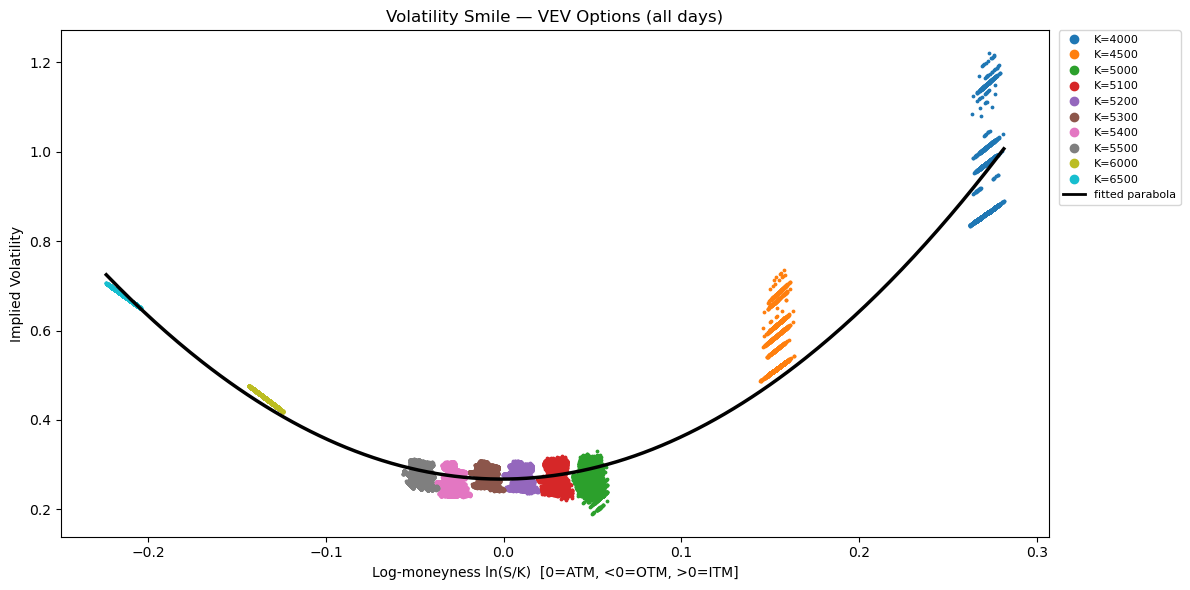

In [111]:
STRIKE_COLORS = plt.cm.tab10(np.linspace(0, 1, len(STRIKES)))
strike_color = dict(zip(STRIKES, STRIKE_COLORS))

fig, ax = plt.subplots(figsize=(12, 6))

for k in STRIKES:
    sub = opts_clean[opts_clean['strike'] == k]
    ax.scatter(sub['log_moneyness'], sub['iv'], alpha=1, s=3,
               color=strike_color[k], label=f'K={k}')

x_all = opts_clean['log_moneyness'].values
y_all = opts_clean['iv'].values
coeffs = np.polyfit(x_all, y_all, 2)
x_grid = np.linspace(x_all.min(), x_all.max(), 300)
ax.plot(x_grid, np.polyval(coeffs, x_grid), 'k-', lw=2.5, label='fitted parabola')
print(f'Parabola coeffs: a={coeffs[0]:.4f}, b={coeffs[1]:.4f}, c={coeffs[2]:.4f}')

ax.set_xlabel('Log-moneyness ln(S/K)  [0=ATM, <0=OTM, >0=ITM]')
ax.set_ylabel('Implied Volatility')
ax.set_title('Volatility Smile — VEV Options (all days)')
handles = [plt.Line2D([0],[0], color=strike_color[k], marker='o', ls='', label=f'K={k}') for k in STRIKES]
handles.append(plt.Line2D([0],[0], color='k', lw=2, label='fitted parabola'))
ax.legend(handles=handles, fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

## Parabola Fit + Detrending

**Why fit a parabola?**

The smile curve is smooth and roughly quadratic in moneyness. By fitting `IV ≈ a*(moneyness)² + b*(moneyness) + c`, we capture the *structural* component — the expected IV at each moneyness level.

**Detrending**: subtract the fitted value from observed IV.
```
residual_IV = observed_IV - parabola_fit(moneyness)
```
Residuals have the smile shape removed. A positive residual means "this option's IV is higher than the smile predicts" → option is *relatively expensive* → candidate to sell. Negative residual → relatively cheap → candidate to buy.

This is powerful because it removes the confound: without detrending, an ITM option always has higher IV than ATM, making raw IV comparisons misleading. After detrending, you're comparing apples to apples.

In [112]:
# Use the same global parabola fitted above
# residual = observed IV - parabola(log_moneyness)
opts_clean = opts_clean.copy()
opts_clean['iv_fit'] = np.polyval(coeffs, opts_clean['log_moneyness'].values)
opts_clean['iv_resid'] = opts_clean['iv'] - opts_clean['iv_fit']
print('done. sample:')
opts_clean[['product','day','timestamp','log_moneyness','iv','iv_fit','iv_resid']].head(10)

done. sample:


,product,day,timestamp,log_moneyness,iv,iv_fit,iv_resid
0,VEV_5400,0,0,-0.028171,0.303428,0.274390,0.029038
1,VEV_6500,0,0,-0.213574,0.677302,0.684802,-0.007499
2,VEV_5500,0,0,-0.046520,0.303375,0.286643,0.016732
3,VEV_5200,0,0,0.009569,0.302603,0.268777,0.033826
4,VEV_5300,0,0,-0.009479,0.306047,0.268315,0.037732
6,VEV_5000,0,0,0.048790,0.302730,0.290875,0.011855
8,VEV_5100,0,0,0.028988,0.303645,0.276159,0.027485
9,VEV_6000,0,0,-0.133531,0.447033,0.429579,0.017454
10,VEV_4500,0,100,0.154246,0.516363,0.491472,0.024890
11,VEV_5000,0,100,0.048885,0.308482,0.290963,0.017519


## Plot detrended IV (residuals)

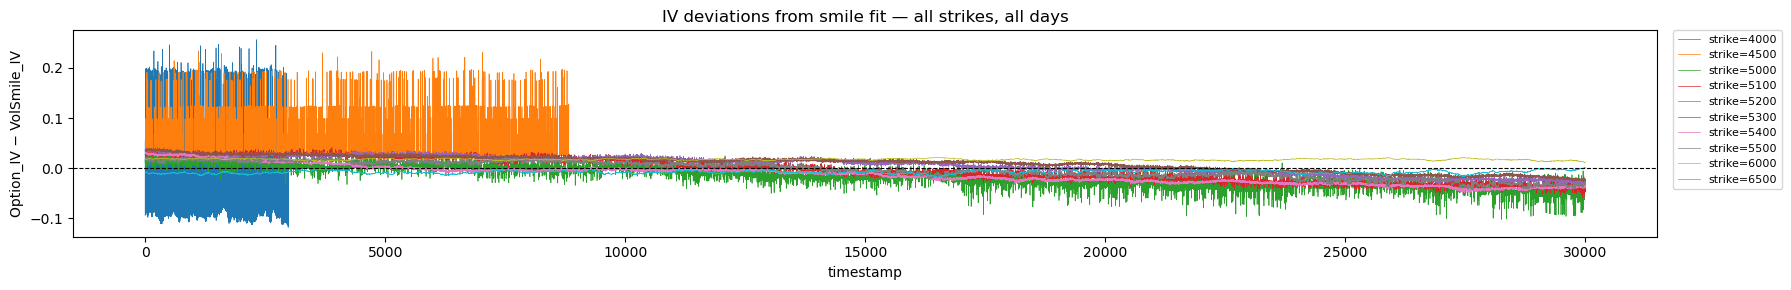

In [113]:
fig, ax = plt.subplots(figsize=(18, 3))

for k in STRIKES:
    sub = (opts_clean[opts_clean['strike'] == k]
           .sort_values(['day', 'timestamp'])
           .copy())
    sub = sub.reset_index(drop=True)
    ax.plot(sub.index, sub['iv_resid'], lw=0.5, alpha=1,
            color=strike_color[k], label=f'strike={k}')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('timestamp')
ax.set_ylabel('Option_IV − VolSmile_IV')
ax.set_title('IV deviations from smile fit — all strikes, all days')
ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

## Price Deviations over Time

Convert IV residuals → price space: `price_dev = mid_price - BS(spot, K, T, iv_fit)`.
Positive = option trading above fair value → sell. Negative → buy.

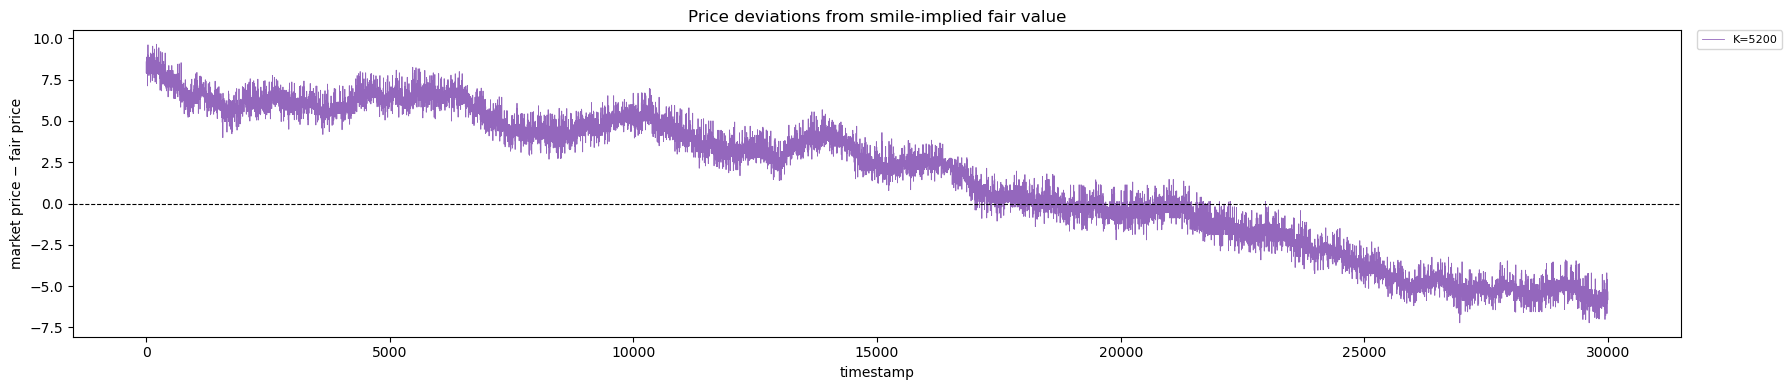

In [127]:
# add more strikes to this list to compare
# FOCUS_STRIKES = [5000,5100,5200,5300,5400,5500]
FOCUS_STRIKES = [5200]

opts_clean['fair_price'] = opts_clean.apply(
    lambda r: bs_call(r['spot'], r['strike'], r['tte'], r['iv_fit']), axis=1
)
opts_clean['price_dev'] = opts_clean['mid_price'] - opts_clean['fair_price']

fig, ax = plt.subplots(figsize=(18, 4))

for k in FOCUS_STRIKES:
    sub = (opts_clean[opts_clean['strike'] == k]
           .sort_values(['day', 'timestamp'])
           .reset_index(drop=True))
    ax.plot(sub.index, sub['price_dev'], lw=0.6,
            color=strike_color[k], label=f'K={k}')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('timestamp')
ax.set_ylabel('market price − fair price')
ax.set_title('Price deviations from smile-implied fair value')
ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

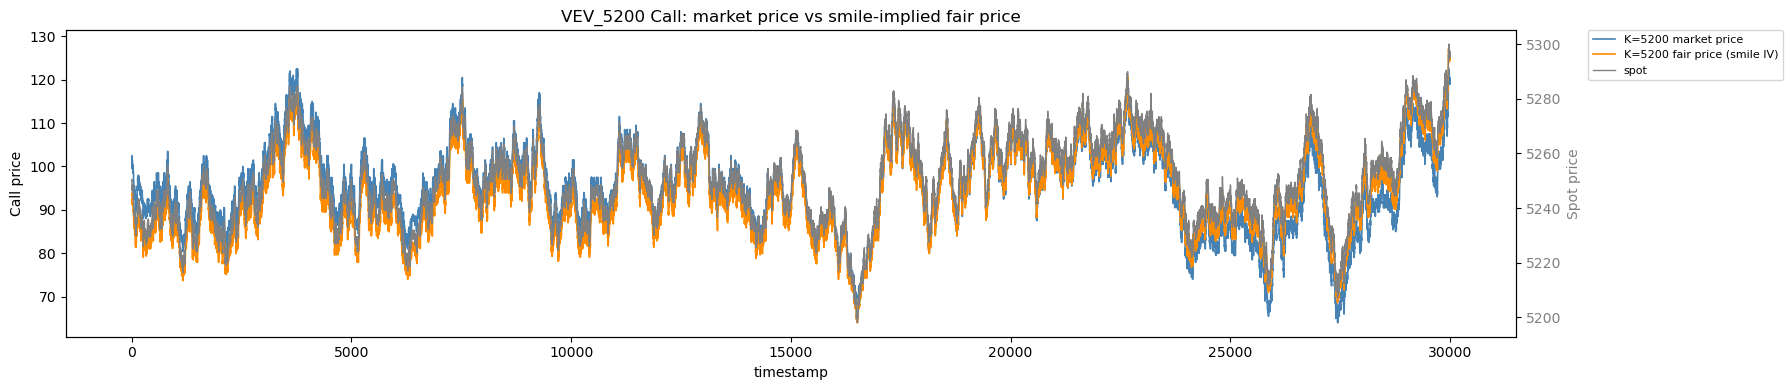

In [136]:
PLOT_STRIKE = 5200  # change to explore other strikes

X_LIM = None   # e.g. (0, 5000)
Y_LIM = None   # set to override; auto-zooms to X_LIM range when None

sub = (opts_clean[opts_clean['strike'] == PLOT_STRIKE]
       .sort_values(['day', 'timestamp'])
       .reset_index(drop=True))

fig, ax1 = plt.subplots(figsize=(18, 4))

ax1.plot(sub.index, sub['mid_price'], lw=1.2, color='steelblue', label=f'K={PLOT_STRIKE} market price')
ax1.plot(sub.index, sub['fair_price'], lw=1.2, color='darkorange', label=f'K={PLOT_STRIKE} fair price (smile IV)')
ax1.set_ylabel('Call price')
ax1.set_xlabel('timestamp')
ax1.set_title(f'VEV_{PLOT_STRIKE} Call: market price vs smile-implied fair price')

if X_LIM:
    ax1.set_xlim(X_LIM)
    if Y_LIM is None:
        mask = (sub.index >= X_LIM[0]) & (sub.index <= X_LIM[1])
        visible = pd.concat([sub.loc[mask, 'mid_price'], sub.loc[mask, 'fair_price']]).dropna()
        if len(visible):
            pad = (visible.max() - visible.min()) * 0.05
            ax1.set_ylim(visible.min() - pad, visible.max() + pad)
if Y_LIM:
    ax1.set_ylim(Y_LIM)

ax2 = ax1.twinx()
spot_ts = spot.sort_values(['day', 'timestamp']).reset_index(drop=True)
ax2.plot(spot_ts.index, spot_ts['spot'], lw=1, color='grey', alpha=1, label='spot')
ax2.set_ylabel('Spot price', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8,
           bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()